# BACKGROUND

DEFINATIONS:


1) Artificial Intelligence -It is a branch of  Computer Science which is used for creating system that is capable of performing tasks that require human intelligence.

2) Machine learning -Simply,it is a subset of artificial intelligence where machine(computer system) learn from data and identify patterns without needing explici and hard coded rules.

3) Deep learning -It is a subset of artificial intelligence and machine learning ,it uses multi-layered to mimic human brain's decision .

4) Data Science-It an interdisciplinary field that uses scientific methods, algorithms, and systems to extract knowledge and insights from raw, structured, and unstructured data






### import libraries

In [62]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, average_precision_score, ConfusionMatrixDisplay

###  1️⃣ Data Retrieval and Collection

In [63]:
def load_data(filepath):
    df = pd.read_csv(filepath)
    return df

df = load_data(filepath='Dataset_Heart_Disease.csv')
df.head()

,Unnamed: 0,age,sex,chest pain type,resting bps,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,4,54,1,3,150,195,0,0,122,0,0.0,1,0


##### Description of datasets:
 Here , i am using datasets which shows whether a patient has heart disease or not ,which  includes all the details of a patient(unnamed,age,sex) and the list of the tests that is required to determine heart disease .

 Each row represent overall details of one patient.
 unnamed-it is simply a index or we cn say serial number provided to each patient 
 age-determines age of a patient 
 sex-determine whether a patient is male or female and here we use data encoding technique i.e female=0 and male =1 
 chestpain type- type of chest pain level
 resting bps-resting blood pressure level (mm Hg)
 cholesterol-Serum cholesterol level that hardens the arteries of heart which directly cause heart disease
 fasting blood sugar- fasting blood sugar is greater than 120 mg/dL( 1=yes, 0=no)
 resting ecg- it determines resting endocardam results
 maximum heart rate- this determines maximum heart rate during exercise
 exercise angina- it shows chest pain during exercise (1=yes,0=no)
 old peak-it simple measures how much ST segment on ecg drops during exercise comapred to rest
 ST slope-  describes the shape of ST segment during peak exrcise on ecg
 target-it shows final heart disease status (1=yes,0=no).


 here we use data encoding features on sex, chest pain type, resting ECG,ST slope and the actual meaning of this encoded data are listed below-

 1) sex- 0=femle,1=male
 2) chest pain type- 1=Typical Angina, 2=Atypical Angina , 3=Non agninal pain, 4=asymtomatic 
 3) Resting ECG- 0= Normal, 1=Abnormal ST-T wave , 2=Left Ventricular Hypertrophy
 4) ST slope- 1=upsloping, 2=flat,3=downsloping



 Here for this dataset we are using logistic regression analysis as we are trying to olve classification problem,instead of predicting a continuous numeriocal value ,we calculate probability to determine whether a patient suffers from heart disease or not (0 or 1 ) by using input features to meet the target goal .

 input features(X)-age,sex,chest pain type,resting bps,cholesterol,fasting blood sugar,resting ecg,max heart rate	exercise angina,oldpeak	,ST slope

 output feature(Y)-target
 main goal- to predict whether a patient has heart disease or not (1=yes,0=no)	



### 2️⃣ Data Cleaning

#### Handling the missing values and dropping the duplicates

In [64]:
df.shape


(1048, 13)

In [65]:
df.isnull().sum()

Unnamed: 0             0
age                    0
sex                    0
chest pain type        0
resting bps            0
cholesterol            0
fasting blood sugar    0
resting ecg            0
max heart rate         0
exercise angina        0
oldpeak                0
ST slope               0
target                 0
dtype: int64

In [66]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1043    False
1044    False
1045    False
1046    False
1047    False
Length: 1048, dtype: bool

In [67]:
df.duplicated().sum()

np.int64(0)

#### here we determine the datatypes of given dataset features

In [68]:
df.dtypes

Unnamed: 0               int64
age                      int64
sex                      int64
chest pain type          int64
resting bps              int64
cholesterol              int64
fasting blood sugar      int64
resting ecg              int64
max heart rate           int64
exercise angina          int64
oldpeak                float64
ST slope                 int64
target                   int64
dtype: object

In [69]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    drop="first",
    sparse_output=False,
    handle_unknown="ignore"
)

#### Dropping  the column unnamed:0 because it useless in the given dataset

In [70]:
df = df.drop(columns=["Unnamed: 0"])

### 3️⃣ Feature Design
Select Cholesterol as the only input feature

Separate features (X) and target (y)

Explain why cholesterol may be a relevant predictor

#### AS CHOLESTEROL CAUSE PLAGUE IN ARTERIES OF HEART WHICH DIRECTLY CAUSE THE RISK OF CARDIOVASCULAR DISEASE BUT ALSO CHOLESTEROL AND HEARTDISEAE DO NOT HAVE THAT STRONG RELATIONSHIP 

In [71]:
correlation = df['cholesterol'].corr(df['target'])
print("Correlation with target:", correlation)

Correlation with target: 0.05621590925424719


#### BY THE ABOVE RESULT WE CAN CONCLUDE THAT CHOLESTEROL AND HEART DISEASE HAVE VERY  WEAK POSTIVE CORRELATION

In [72]:
X=df[['cholesterol']]
Y=df['target']

### 4️⃣ Algorithm Selection
Choose Logistic Regression 

Explain why logistic regression is suitable for binary classification

Here for this dataset we are using logistic regression analysis as we are trying to solve binary classification problem,instead of predicting a continuous numerical value ,we calculate probability to determine whether a patient suffers from heart disease or not (0 or 1 ) by using input features to meet the target goal .

 input features(X)-cholesterol

 output feature(Y)-target
 main goal- to predict whether a patient has heart disease or not (1=yes,0=no)	


### 5️⃣ Loss Function Selection
Use Binary Cross-Entropy (Log Loss)

Briefly explain how this loss function works

Binary Cross-Entropy (Log Loss) is used for binary classification problems where the target variable has two classes (0 and 1). It measures the difference between the actual class label and the probability predicted by the model. Correct predictions result in a low loss value, while incorrect predictions result in a high loss value. The model aims to minimize this loss during training, leading to more accurate predictions.

Formula: Loss=−[ylog(p)+(1−y)log(1−p)]

Where:y = actual class label (0 or 1), p = predicted probability of class 1.
We use binary cross entropy because it is suitable for binary classification tasks, It works well with Logistic Regression and penalizes confident incorrect predictions more heavily than less confident ones.

### 6️⃣ Model Learning (Training)
Split the dataset into training and testing sets

Train the logistic regression model

Explain how model parameters are learned

In [73]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X,Y, test_size=0.3, random_state=42, stratify=Y)

In [74]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((733, 1), (315, 1), (733,), (315,))

### TRAINING MODEL

In [75]:
x_train_scaled = StandardScaler().fit_transform(x_train)
x_test_scaled = StandardScaler().fit_transform(x_test)
print("trained_scaled: ", x_train_scaled[:3])
print("test_scaled: ", x_test_scaled[:3])

trained_scaled:  [[ 0.92679441]
 [-0.41822084]
 [-0.4002873 ]]
test_scaled:  [[-1.00949422]
 [-1.12629213]
 [ 0.42545165]]


In [76]:
from sklearn.linear_model import LogisticRegression
logistic_model = LogisticRegression(C=np.inf, random_state=42)
logistic_model.fit(x_train_scaled, y_train)

,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",inf
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [77]:
logistic_model.coef_

array([[0.09697717]])

In [78]:
y_pred = logistic_model.predict(x_test_scaled)
y_pred

array([0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1,

In [79]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.53      0.64      0.58       159
           1       0.53      0.42      0.47       156

    accuracy                           0.53       315
   macro avg       0.53      0.53      0.52       315
weighted avg       0.53      0.53      0.52       315



Confusion Matrix
[[101  58]
 [ 90  66]]


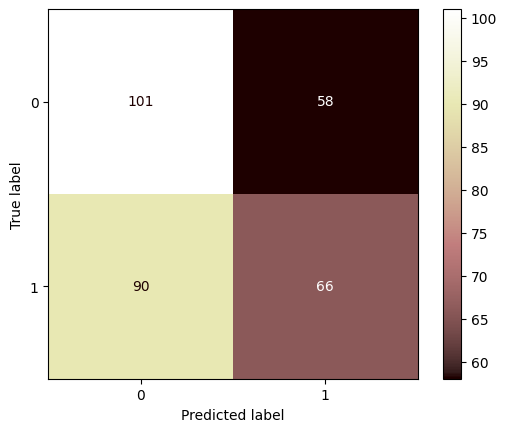

In [80]:
print("Confusion Matrix")
confusion_mat = confusion_matrix(y_true=y_test, y_pred=y_pred)
ConfusionMatrixDisplay(confusion_matrix=confusion_mat).plot(cmap="pink")
print(confusion_mat)

Our main  goal is to detect heart disease cases accurately and it is much important to reduce false negative as much as possible  that means model should correctly identify most patients who actually have disease.

#### 7️⃣ Model Evaluation
Evaluate the model using appropriate classification metrics, such as:

Accuracy
Precision
Recall
F1-score
Also, print the confusion matrix.

In [81]:
y_score = logistic_model.predict_proba(x_test_scaled)[:, 1]

In [84]:
from sklearn.metrics import (accuracy_score, precision_score,recall_score,f1_score,confusion_matrix,ConfusionMatrixDisplay)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.5301587301587302
Precision: 0.532258064516129
Recall: 0.4230769230769231
F1 Score: 0.4714285714285714


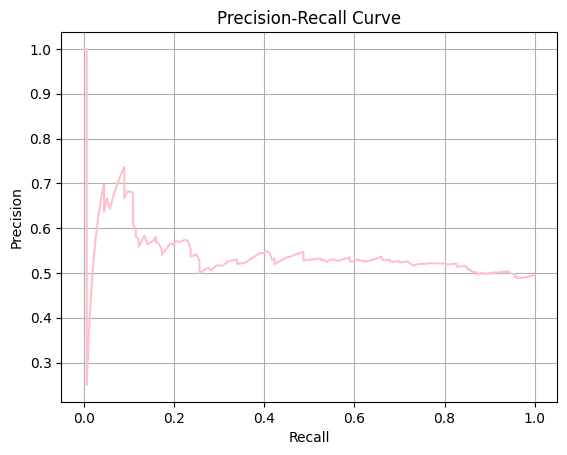

Average Precision Score: 0.544


In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
precision, recall, _ = precision_recall_curve(y_test, y_score)
pr_auc = average_precision_score(y_test, y_score)
plt.plot(recall, precision, color='pink')
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)
plt.show()
print(f"Average Precision Score: {pr_auc:.3f}")